# Predictive Paradox — Electricity Demand Forecasting Pipeline

**Objective:** Predict next hour's electricity demand (`demand_mw` at t+1) using classical ML.

1. Structural Setup & Duplicates
2. Half-Hourly Aggregation
3. Enforcing Hourly Frequency & Anomaly Detection
4. Missing Value Imputation (Zero Data Leakage)
5. Merging Contextual Datasets
6. Feature Engineering
7. Train/Test Split & Modeling
8. Evaluation & Reporting

## 0. Imports & Configuration

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("XGBoost available")
except ImportError:
    XGB_AVAILABLE = False
    print("  XGBoost not found, will use GradientBoosting")

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
    print("LightGBM available")
except ImportError:
    LGB_AVAILABLE = False
    print("  LightGBM not found")

plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

 XGBoost available
 LightGBM available


In [83]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Ankit\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


---
## Phase 1: Structural Setup & Duplicates

**Goal:** Load raw data, parse timestamps correctly, and resolve duplicate entries using mean aggregation.

In [84]:
df = pd.read_excel('PGCB_date_power_demand.xlsx')


print("RAW DATA OVERVIEW")

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
display(df.head())

 RAW DATA OVERVIEW
Shape: (92650, 15)
Columns: ['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'remarks']

Dtypes:
datetime                datetime64[us]
generation_mw                  float64
demand_mw                        int64
load_shedding                    int64
gas                              int64
liquid_fuel                      int64
coal                             int64
hydro                            int64
solar                          float64
wind                           float64
india_bheramara_hvdc             int64
india_tripura                    int64
india_adani                    float64
nepal                          float64
remarks                            str
dtype: object

First 5 rows:


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 22:00:00,6323.00,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 21:00:00,6667.00,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 19:00:00,6897.00,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,2015-04-19 18:30:00,6933.00,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,2015-04-19 18:00:00,6874.00,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN


In [85]:
time_col = 'datetime'  

df[time_col] = pd.to_datetime(df[time_col])
df = df.set_index(time_col)
df = df.sort_index()

print(f"Date Range: {df.index.min()} → {df.index.max()}")
print(f"Total Records: {len(df):,}")
print(f"\nUnique timestamps: {df.index.nunique():,}")
print(f"Total rows: {len(df):,}")

 Date Range: 2015-04-19 00:00:00 → 2025-06-17 12:00:00
 Total Records: 92,650

Unique timestamps: 92,218
Total rows: 92,650


In [86]:
n_duplicates = df.index.duplicated().sum()
print(f"Duplicate timestamps found: {n_duplicates:,}")

if n_duplicates > 0:
    print("\nSample duplicate entries:")
    dup_mask = df.index.duplicated(keep=False)
    display(df[dup_mask].head(10))

df = df.groupby(df.index).mean(numeric_only=True)

print(f"\n After deduplication: {len(df):,} rows")
print(f"   Removed {n_duplicates:,} duplicate rows")

 Duplicate timestamps found: 432

Sample duplicate entries:


,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
datetime,,,,,,,,,,,,,,
2015-04-22 21:00:00,5811.00,5811,0,4158,1021,162,30,NaN,NaN,440,0,NaN,NaN,NaN
2015-04-22 21:00:00,5368.00,5368,0,4184,552,160,30,NaN,NaN,442,0,NaN,NaN,NaN
2015-04-23 00:00:00,5726.00,5726,0,4199,790,158,46,NaN,NaN,433,0,NaN,NaN,NaN
2015-04-23 00:00:00,3976.00,3976,0,3116,230,158,30,NaN,NaN,442,0,NaN,NaN,NaN
2015-04-27 00:00:00,5236.00,5236,0,4417,159,162,46,NaN,NaN,452,0,NaN,NaN,NaN
2015-04-27 00:00:00,4800.00,4800,0,3954,117,166,46,NaN,NaN,458,0,NaN,NaN,NaN
2015-04-27 00:00:00,5459.00,5459,0,4457,363,148,45,NaN,NaN,458,0,NaN,NaN,NaN
2015-04-30 00:00:00,5809.00,5809,0,4901,257,154,46,NaN,NaN,451,0,NaN,NaN,NaN
2015-04-30 00:00:00,6065.00,6065,0,4239,1187,156,32,NaN,NaN,451,0,NaN,NaN,NaN



 After deduplication: 92,218 rows
   Removed 432 duplicate rows


---
## Phase 2: Half-Hourly Aggregation

**Goal:** Handle irregular `:30` timestamps by merging them into their anchor `:00` hour using anchor-biased weighting (80% hourly + 20% half-hourly). The 80/20 split reflects that the `:00` reading is the official anchor; `:30` is a minor supplemental reading.

In [87]:
minute_counts = df.index.minute.value_counts().sort_index()
print("Minute distribution in timestamps:")
print(minute_counts)

has_half_hourly = 30 in minute_counts.index
print(f"\n{'Half-hourly (:30) timestamps detected!' if has_half_hourly else ' All timestamps are on the hour'}")

Minute distribution in timestamps:
datetime
0     88046
30     4172
Name: count, dtype: int64

Half-hourly (:30) timestamps detected!


In [88]:
if has_half_hourly:
    hourly_df    = df[df.index.minute == 0].copy()
    half_hourly_df = df[df.index.minute == 30].copy()

    print(f"   Hourly (:00) rows   : {len(hourly_df):,}")
    print(f"   Half-hourly (:30) rows: {len(half_hourly_df):,}")

    half_hourly_df.index = half_hourly_df.index - pd.Timedelta(minutes=30)

    common_idx = hourly_df.index.intersection(half_hourly_df.index)
    print(f"   Common timestamps to merge: {len(common_idx):,}")

    for col in ['demand_mw']:
        if col in hourly_df.columns and col in half_hourly_df.columns:
            hourly_df.loc[common_idx, col] = (
                hourly_df.loc[common_idx, col] * 0.8 +
                half_hourly_df.loc[common_idx, col] * 0.2
            )

    only_half = half_hourly_df.index.difference(hourly_df.index)
    if len(only_half) > 0:
        hourly_df = pd.concat([hourly_df, half_hourly_df.loc[only_half]])
        hourly_df = hourly_df.sort_index()

    df = hourly_df.copy()
    print(f"\nAfter half-hourly aggregation: {len(df):,} rows")
else:
    print("No half-hourly data — skipping Phase 2")

   Hourly (:00) rows   : 88,046
   Half-hourly (:30) rows: 4,172
   Common timestamps to merge: 4,168

After half-hourly aggregation: 88,050 rows


---
## Phase 3: Enforcing Hourly Frequency & Anomaly Detection

**Goal:** Force strict 1-hour frequency grid (NaN for missing hours), then detect and remove extreme spikes using a combined Z-Score + IQR strategy (a point is only flagged if BOTH methods agree, reducing false positives).

In [89]:
df_before = len(df)
df = df.asfreq('h') 

n_gaps = df['demand_mw'].isna().sum()
print(f"Rows before asfreq : {df_before:,}")
print(f"Rows after  asfreq : {len(df):,}")
print(f"Missing hours inserted: {len(df) - df_before:,}")
print(f"Total NaN in demand_mw: {n_gaps:,} ({100*n_gaps/len(df):.2f}%)")

Rows before asfreq : 88,050
Rows after  asfreq : 89,101
Missing hours inserted: 1,051
Total NaN in demand_mw: 1,051 (1.18%)


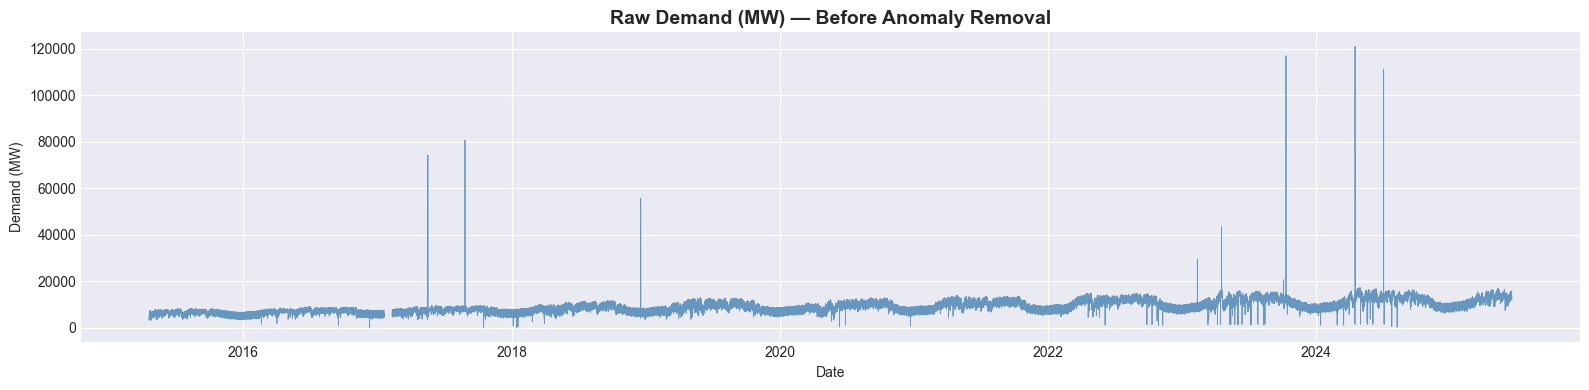

Saved: 01_raw_demand.png


In [90]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df['demand_mw'], linewidth=0.6, color='steelblue', alpha=0.8)
ax.set_title('Raw Demand (MW) — Before Anomaly Removal', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Demand (MW)')
plt.tight_layout()
plt.savefig('01_raw_demand.png', dpi=150, bbox_inches='tight')
plt.show()

In [91]:
WINDOW   = 48     
Z_THRESH = 4    

rolling_mean = df['demand_mw'].shift(1).rolling(window=WINDOW, min_periods=12).mean()
rolling_std  = df['demand_mw'].shift(1).rolling(window=WINDOW, min_periods=12).std()
z_scores     = (df['demand_mw'] - rolling_mean) / rolling_std
z_score_mask = z_scores.abs() > Z_THRESH

Q1 = df['demand_mw'].quantile(0.25)
Q3 = df['demand_mw'].quantile(0.75)
IQR = Q3 - Q1
iqr_lower = Q1 - 3.0 * IQR   
iqr_upper = Q3 + 3.0 * IQR
iqr_mask = (df['demand_mw'] < iqr_lower) | (df['demand_mw'] > iqr_upper)


anomaly_mask = z_score_mask & iqr_mask

n_z    = z_score_mask.sum()
n_iqr  = iqr_mask.sum()
n_both = anomaly_mask.sum()

print(f"Anomaly Detection Summary (Z + IQR combined)")
print(f"Z-Score flagged  : {n_z:,} ({100*n_z/len(df):.3f}%)")
print(f"IQR flagged      : {n_iqr:,} ({100*n_iqr/len(df):.3f}%)")
print(f"Both agree (true anomalies): {n_both:,} ({100*n_both/len(df):.3f}%)")
print(f"IQR bounds: [{iqr_lower:.1f}, {iqr_upper:.1f}] MW")

if 100*n_both/len(df) > 2:
    print("WARNING: >2% flagged — consider raising thresholds")
elif 100*n_both/len(df) < 0.01:
    print("WARNING: Very few flagged — thresholds may be too loose")
else:
    print("Flagged % looks reasonable")

spike_log = df[anomaly_mask][['demand_mw']].copy()
spike_log['z_score'] = z_scores[anomaly_mask]
print(f"\nSample combined anomalies:")
display(spike_log.head(10))

df.loc[anomaly_mask, 'demand_mw'] = np.nan
print(f"\n{n_both} combined anomalies removed (set to NaN for imputation)")

Anomaly Detection Summary (Z + IQR combined)
Z-Score flagged  : 77 (0.086%)
IQR flagged      : 8 (0.009%)
Both agree (true anomalies): 8 (0.009%)
IQR bounds: [-4694.0, 22060.0] MW

Sample combined anomalies:


,demand_mw,z_score
datetime,,
2017-05-17 12:00:00,74223.00,46.67
2017-08-26 15:00:00,80689.00,112.09
2018-12-18 08:00:00,55639.00,46.94
2023-02-11 18:00:00,29404.00,20.69
2023-04-18 18:00:00,43410.00,38.02
2023-10-11 03:00:00,117000.00,101.20
2024-04-16 07:00:00,121000.00,56.78
2024-07-03 05:00:00,111140.00,113.84



8 combined anomalies removed (set to NaN for imputation)


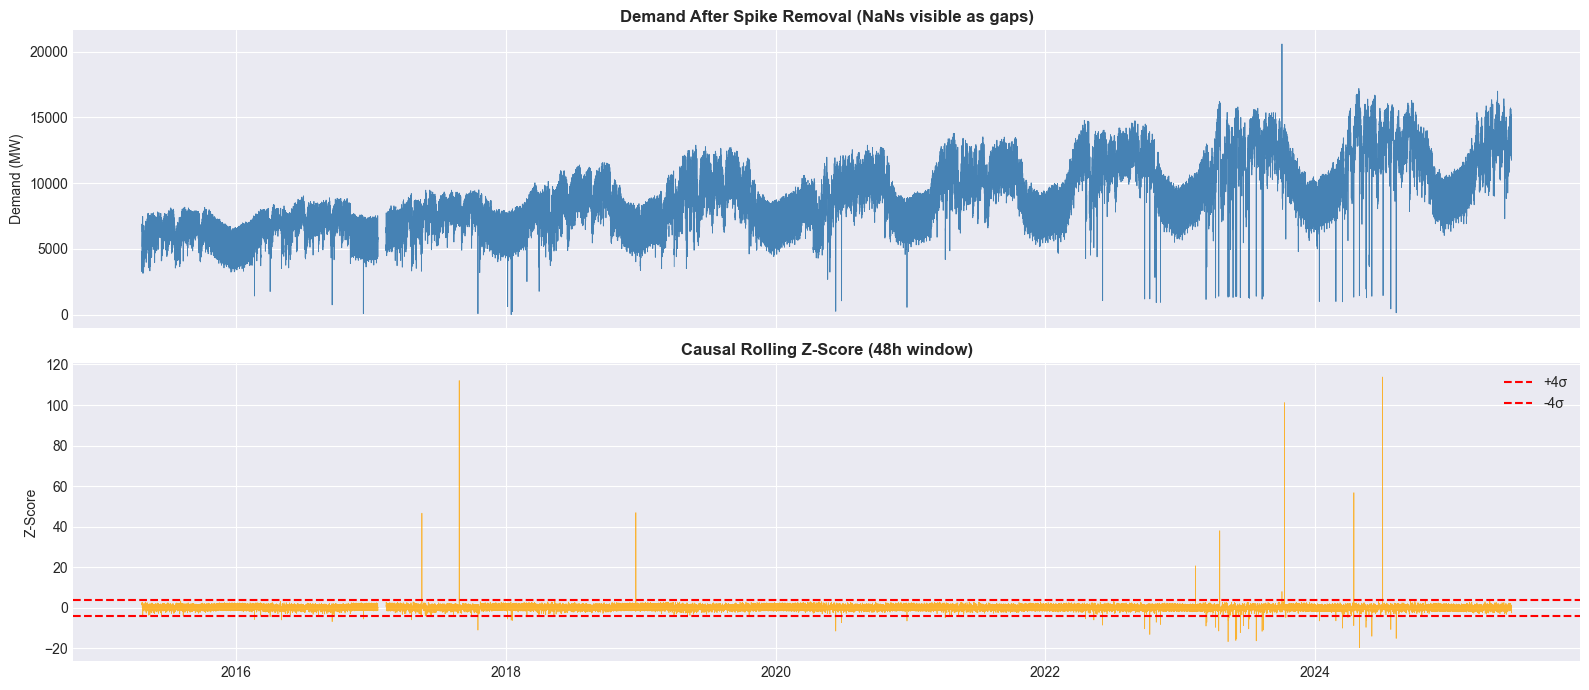

Saved: 02_anomaly_detection.png


In [92]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df.index, df['demand_mw'], linewidth=0.6, color='steelblue')
axes[0].set_title('Demand After Spike Removal (NaNs visible as gaps)', fontweight='bold')
axes[0].set_ylabel('Demand (MW)')

axes[1].plot(z_scores.index, z_scores, linewidth=0.5, color='orange', alpha=0.8)
axes[1].axhline(Z_THRESH, color='red', linestyle='--', label=f'+{Z_THRESH}σ')
axes[1].axhline(-Z_THRESH, color='red', linestyle='--', label=f'-{Z_THRESH}σ')
axes[1].set_title('Causal Rolling Z-Score (48h window)', fontweight='bold')
axes[1].set_ylabel('Z-Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('02_anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 4: Missing Value Imputation (Zero Data Leakage)

**Goal:** Fill all NaNs (original gaps + spike removals) using a strictly causal two-pass strategy:
- **Pass 1:** 3-hour causal rolling **median** (handles short gaps — robust against nearby spikes)
- **Pass 2:** Same hour, previous day — lag_24 (handles longer gaps)
- **Pass 3:** Same hour, previous week — lag_168 (edge case fallback)

In [93]:
n_missing_before = df['demand_mw'].isna().sum()
print(f"NaN count before imputation: {n_missing_before:,}")

pass1_fill = df['demand_mw'].shift(1).rolling(window=3, min_periods=1).median()
df['demand_mw'] = df['demand_mw'].fillna(pass1_fill)
after_pass1 = df['demand_mw'].isna().sum()
print(f"After Pass 1 (3h rolling median): {after_pass1:,} NaNs remaining")

pass2_fill = df['demand_mw'].shift(24)
df['demand_mw'] = df['demand_mw'].fillna(pass2_fill)
after_pass2 = df['demand_mw'].isna().sum()
print(f"After Pass 2 (lag-24h)   : {after_pass2:,} NaNs remaining")

pass3_fill = df['demand_mw'].shift(168)
df['demand_mw'] = df['demand_mw'].fillna(pass3_fill)
after_pass3 = df['demand_mw'].isna().sum()
print(f"After Pass 3 (lag-168h)  : {after_pass3:,} NaNs remaining")

if after_pass3 > 0:
    df['demand_mw'] = df['demand_mw'].interpolate(method='linear', limit_direction='forward')
    after_pass4 = df['demand_mw'].isna().sum()
    print(f"After Pass 4 (linear interp): {after_pass4:,} NaNs remaining")

print(f"\nTotal NaNs filled: {n_missing_before - df['demand_mw'].isna().sum():,}")
print(f"Final NaN count: {df['demand_mw'].isna().sum()}")

NaN count before imputation: 1,059
After Pass 1 (3h rolling median): 742 NaNs remaining
After Pass 2 (lag-24h)   : 500 NaNs remaining
After Pass 3 (lag-168h)  : 325 NaNs remaining
After Pass 4 (linear interp): 0 NaNs remaining

Total NaNs filled: 1,059
Final NaN count: 0


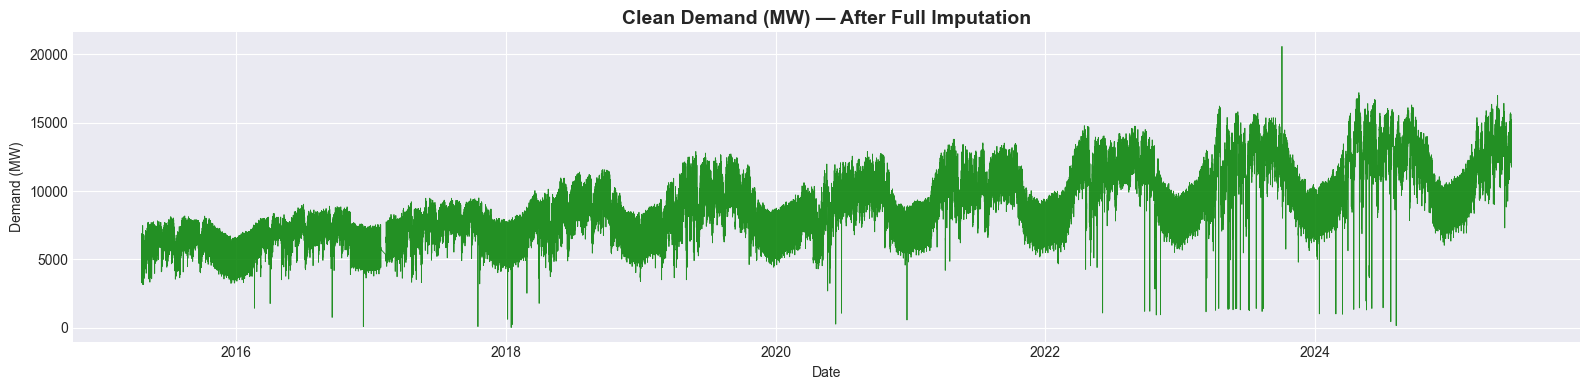

Saved: 03_clean_demand.png


In [94]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df['demand_mw'], linewidth=0.6, color='green', alpha=0.85)
ax.set_title('Clean Demand (MW) — After Full Imputation', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Demand (MW)')
plt.tight_layout()
plt.savefig('03_clean_demand.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Phase 5: Merging Contextual Datasets

**Goal:** Merge weather data (hourly) and macroeconomic data (annual → broadcast to every hour of that year) into the main demand dataframe.

In [95]:
weather = pd.read_excel('weather_data.xlsx', skiprows=3)

print("Weather Data Overview:")
print(f"Shape: {weather.shape}")
print(f"Columns: {weather.columns.tolist()}")
display(weather.head(3))

Weather Data Overview:
Shape: (107304, 10)
Columns: ['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)', 'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)', 'cloud_cover (%)', 'sunshine_duration (s)']


,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.90,89,13.30,0.00,12.10,16.40,313,0,0.00
1,2014-01-01 01:00:00,13.60,91,13.20,0.00,12.10,16.00,317,0,0.00
2,2014-01-01 02:00:00,13.30,91,12.80,0.00,11.90,15.70,317,0,0.00


In [96]:
weather.columns = weather.columns.str.strip()

In [97]:
weather.columns = weather.columns.str.strip()

weather_time_col = weather.columns[0] 

print(f"Successfully found time column: '{weather_time_col}'")

weather[weather_time_col] = pd.to_datetime(weather[weather_time_col])
weather = weather.set_index(weather_time_col).sort_index()

weather = weather.groupby(weather.index).mean(numeric_only=True)

weather = weather.asfreq('h')

for col in weather.columns:
    n_nan = weather[col].isna().sum()
    if n_nan > 0:
        pct = 100 * n_nan / len(weather)
        print(f"   {col}: {n_nan:,} NaNs ({pct:.2f}%)")

MAX_WEATHER_GAP = 6  
weather_filled = weather.ffill(limit=MAX_WEATHER_GAP)

weather_filled = weather_filled.bfill(limit=MAX_WEATHER_GAP)

weather_filled = weather_filled.interpolate(method='linear')

print(f"\nWeather data cleaned. Remaining NaNs: {weather_filled.isna().sum().sum()}")

Successfully found time column: 'time'

Weather data cleaned. Remaining NaNs: 0


In [98]:
df = df.join(weather_filled, how='left')
print(f"After weather merge: {df.shape}")
print(f"New columns: {[c for c in df.columns if c in weather_filled.columns]}")

After weather merge: (89101, 22)
New columns: ['temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)', 'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)', 'cloud_cover (%)', 'sunshine_duration (s)']


In [99]:
econ = pd.read_csv('economic_full_1.csv')

print("Economic Data Overview:")
print(f"Shape: {econ.shape}")
print(f"Columns: {econ.columns.tolist()}")
display(econ.head())

Economic Data Overview:
Shape: (1516, 69)
Columns: ['Country Name', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


,Country Name,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,...,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,X,"Intentional homicides, male (per 100,000 male)",VC.IHR.PSRC.MA.P5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,X,Battle-related deaths (number of people),VC.BTL.DETH,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,62.00,57.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.00,47.00,NaN,NaN,2.00,NaN,2.00,NaN,2.00,NaN
2,X,Voice and Accountability: Percentile Rank,VA.PER.RNK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,37.31,31.84,27.88,30.29,32.21,31.25,33.17,38.39,36.97,36.15,34.74,34.74,32.02,30.05,30.54,30.05,27.18,26.57,26.57,28.02,28.02,27.45,NaN,NaN
3,X,Transport services (% of commercial service ex...,TX.VAL.TRAN.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.89,31.88,25.36,28.04,22.82,23.09,...,29.50,26.78,14.82,16.84,16.30,9.98,8.17,10.68,15.17,14.22,19.46,27.92,32.55,23.91,23.94,20.82,21.48,22.05,19.56,22.26,27.16,25.52,17.18,23.50,NaN
4,X,"Computer, communications and other services (%...",TX.VAL.OTHR.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.58,58.18,67.11,62.00,67.94,70.53,...,46.24,52.66,67.34,65.14,70.82,77.60,81.29,78.75,72.22,75.36,69.73,59.19,54.91,62.32,62.90,64.07,57.20,62.31,63.58,67.40,64.57,63.54,67.82,65.57,NaN


In [100]:
import numpy as np

econ = pd.read_csv('economic_full_1.csv')

econ = econ.melt(
    id_vars=['Country Name', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Value'
)
econ = econ.pivot_table(
    index='Year',
    columns='Indicator Name',
    values='Value',
    aggfunc='mean'
).reset_index()

econ.columns = [str(col).strip() for col in econ.columns]
econ = econ.apply(pd.to_numeric, errors='coerce')
econ['Year'] = econ['Year'].astype(int)
econ = econ.fillna(econ.mean(numeric_only=True))

df = df.reset_index()          
df['year_temp'] = df['datetime'].dt.year

df = df.merge(econ, left_on='year_temp', right_on='Year', how='left')

df = df.set_index('datetime').sort_index()
df = df.drop(columns=['year_temp', 'Year'], errors='ignore')

df = df.ffill().bfill()

print(f"Index type: {type(df.index)}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"Shape after econ merge: {df.shape}")

Index type: <class 'pandas.DatetimeIndex'>
Date range: 2015-04-19 00:00:00 → 2025-06-17 12:00:00
Shape after econ merge: (89101, 1482)
Sab sahi ho gaya! New Columns: 1482
Random Forest training ke liye data taiyar hai.


In [101]:
if not isinstance(df.index, pd.DatetimeIndex):
    
    dt_cols = df.select_dtypes(include='datetime64').columns.tolist()
    if dt_cols:
        df = df.set_index(dt_cols[0]).sort_index()
        print(f"Datetime index restored using column: {dt_cols[0]}")

print(f"Final dataframe shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"\nColumn list:")
print(df.columns.tolist())

Final dataframe shape: (89101, 1482)
Date range: 2015-04-19 00:00:00 → 2025-06-17 12:00:00

Column list:
['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura', 'india_adani', 'nepal', 'temperature_2m (°C)', 'relative_humidity_2m (%)', 'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)', 'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)', 'cloud_cover (%)', 'sunshine_duration (s)', 'ARI treatment (% of children under 5 taken to a health provider)', 'Access to clean fuels and technologies for cooking (% of population)', 'Access to clean fuels and technologies for cooking, rural (% of rural population)', 'Access to clean fuels and technologies for cooking, urban (% of urban population)', 'Access to electricity (% of population)', 'Access to electricity, rural (% of rural population)', 'Access to electricity, urban (% of urban population)', 'Account ownership at a financial 

---
## Phase 6: Feature Engineering

**Goal:** Since classical ML treats observations independently, we must manually encode the concept of "time" through:
1. **Calendar features** — hour, day, month, cyclic sin/cos encoding
2. **Lag features** — past demand values the model can "look back" at
3. **Rolling aggregate features** — recent trends and volatility
4. **Weather Regime Clustering** — DBSCAN/KMeans clusters of (temp, humidity, wind) into regime labels
5. **Daily Load Profile Clustering** — K-Means on 24-hour demand shapes to classify day archetypes
6. **Demand DNA Fingerprint** — peer hour comparison, trajectory slope/concavity, cross-hour interaction, time-to-event
7. **Target shift** — predict t+1 (next hour's demand)

In [102]:
df.index = pd.to_datetime(df.index)
df['hour']         = df.index.hour
df['day_of_week']  = df.index.dayofweek
df['day_of_month'] = df.index.day
df['month']        = df.index.month
df['quarter']      = df.index.quarter
df['year']         = df.index.year
df['week_of_year'] = df.index.isocalendar().week.astype(int)
df['day_of_year']  = df.index.dayofyear

df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['is_weekday']   = (df['day_of_week'] < 5).astype(int)

df['is_peak_hour'] = df['hour'].isin([18, 19, 20, 21, 22]).astype(int)

df['is_night']     = df['hour'].isin([0, 1, 2, 3, 4, 5]).astype(int)

df['hour_sin']     = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']     = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin']    = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']    = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin']      = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']      = np.cos(2 * np.pi * df['day_of_week'] / 7)

print("Calendar features created:")
calendar_cols = ['hour','day_of_week','day_of_month','month','quarter',
                 'is_weekend','is_peak_hour','is_night',
                 'hour_sin','hour_cos','month_sin','month_cos']
print(f" {calendar_cols}")


!pip install holidays
import holidays

bd_hols = holidays.Bangladesh(years=range(2015, 2025))
df['is_holiday'] = df.index.normalize().isin(bd_hols).astype(int)

ramadan_ranges = [
    ('2015-06-18', '2015-07-17'),
    ('2016-06-06', '2016-07-05'),
    ('2017-05-27', '2017-06-24'),
    ('2018-05-16', '2018-06-14'),
    ('2019-05-05', '2020-06-03'),
    ('2020-04-24', '2020-05-23'),
    ('2021-04-13', '2021-05-12'),
    ('2022-04-02', '2022-05-01'),
    ('2023-03-23', '2023-04-21'),
    ('2024-03-11', '2024-04-09'),
]

df['is_ramadan'] = 0
for start, end in ramadan_ranges:
    df.loc[start:end, 'is_ramadan'] = 1

print("Holiday + Ramadan features added!")
print(f"Holidays found: {df['is_holiday'].sum()}")
print(f"Ramadan hours: {df['is_ramadan'].sum()}")

Calendar features created:
 ['hour', 'day_of_week', 'day_of_month', 'month', 'quarter', 'is_weekend', 'is_peak_hour', 'is_night', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']
Defaulting to user installation because normal site-packages is not writeable
Holiday + Ramadan features added!
Holidays found: 0
Ramadan hours: 15240



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Ankit\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [103]:
lag_hours = [
    1, 2, 3, 6, 12,
    23, 24, 25,      
    47, 48, 49,      
    167, 168, 169,   
    336
]
for lag in lag_hours:
    df[f'lag_{lag}h'] = df['demand_mw'].shift(lag)

print(f"Lag features created: {[f'lag_{l}h' for l in lag_hours]}")

Lag features created: ['lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_23h', 'lag_24h', 'lag_25h', 'lag_47h', 'lag_48h', 'lag_49h', 'lag_167h', 'lag_168h', 'lag_169h', 'lag_336h']


In [104]:
shifted = df['demand_mw'].shift(1)

windows = {
    3:   '3h',
    6:   '6h',
    12:  '12h',
    24:  '24h',
    48:  '48h',
    168: '1w',
}

for w, label in windows.items():
    df[f'roll_mean_{label}']  = shifted.rolling(window=w, min_periods=max(1, w//4)).mean()
    df[f'roll_std_{label}']   = shifted.rolling(window=w, min_periods=max(1, w//4)).std()

df['roll_max_24h'] = shifted.rolling(window=24, min_periods=6).max()
df['roll_min_24h'] = shifted.rolling(window=24, min_periods=6).min()
df['roll_range_24h'] = df['roll_max_24h'] - df['roll_min_24h']

df['momentum_3v24'] = df['roll_mean_3h'] - df['roll_mean_24h']

shifted = df['demand_mw'].shift(1)
for span in [3, 6, 12, 24]:
    df[f'ewm_{span}h'] = shifted.ewm(span=span, adjust=False).mean()

roll_cols = [c for c in df.columns if c.startswith('roll_') or c == 'momentum_3v24']
print(f"Rolling features created: {roll_cols}")

Rolling features created: ['roll_mean_3h', 'roll_std_3h', 'roll_mean_6h', 'roll_std_6h', 'roll_mean_12h', 'roll_std_12h', 'roll_mean_24h', 'roll_std_24h', 'roll_mean_48h', 'roll_std_48h', 'roll_mean_1w', 'roll_std_1w', 'roll_max_24h', 'roll_min_24h', 'roll_range_24h', 'momentum_3v24']


In [105]:
from sklearn.cluster import KMeans

N_PROFILE_CLUSTERS = 4  
try:
    df_temp = df[['demand_mw']].copy()
    df_temp['date'] = df_temp.index.date
    df_temp['hour'] = df_temp.index.hour


    daily_profiles = df_temp.pivot_table(
        index='date', columns='hour', values='demand_mw', aggfunc='mean'
    ).dropna()  

    if len(daily_profiles) >= N_PROFILE_CLUSTERS * 5:
        from sklearn.preprocessing import StandardScaler
        profile_scaler = StandardScaler()
        profiles_scaled = profile_scaler.fit_transform(daily_profiles)

        kmeans_profile = KMeans(n_clusters=N_PROFILE_CLUSTERS, random_state=42, n_init='auto')
        daily_cluster_labels = kmeans_profile.fit_predict(profiles_scaled)

        date_cluster_map = dict(zip(daily_profiles.index, daily_cluster_labels))

        
        yesterday = (df.index - pd.Timedelta(days=1)).date
        df['daily_load_cluster'] = [date_cluster_map.get(d, -1) for d in yesterday]

        df['daily_load_cluster'] = df['daily_load_cluster'].replace(-1, df['daily_load_cluster'].mode()[0])
        df['daily_load_cluster'] = df['daily_load_cluster'].astype(int)

        print(f"Daily Load Profile Clusters (K-Means, k={N_PROFILE_CLUSTERS})")
        print(df['daily_load_cluster'].value_counts().sort_index())
        print("\n'daily_load_cluster' feature added (yesterday's load shape → today's context)")
    else:
        print(f"Not enough complete days ({len(daily_profiles)}) for profile clustering — skipping")
        df['daily_load_cluster'] = 0
except Exception as e:
    print(f"Daily load clustering error: {e}")
    df['daily_load_cluster'] = 0

Daily Load Profile Clusters (K-Means, k=4)
daily_load_cluster
0    27480
1    13525
2    27288
3    20808
Name: count, dtype: int64

'daily_load_cluster' feature added (yesterday's load shape → today's context)


In [106]:
df['peer_hour_mean_7d'] = (
    df.groupby(df.index.hour)['demand_mw']
    .transform(lambda x: x.shift(1).rolling(7*24, min_periods=24).mean())
)
df['peer_hour_std_7d'] = (
    df.groupby(df.index.hour)['demand_mw']
    .transform(lambda x: x.shift(1).rolling(7*24, min_periods=24).std())
)
df['peer_hour_zscore'] = (
    (df['demand_mw'].shift(1) - df['peer_hour_mean_7d']) /
    (df['peer_hour_std_7d'] + 1e-6)
)

df['demand_slope_6h'] = (
    df['demand_mw'].shift(1).rolling(6).apply(
        lambda x: np.polyfit(range(len(x)), x, 1)[0] if len(x) == 6 else np.nan,
        raw=True
    )
)
df['demand_concavity'] = df['demand_slope_6h'] - df['demand_slope_6h'].shift(1)

df['hour_dow_interaction'] = df.index.dayofweek * 24 + df.index.hour

df['hours_to_peak']   = df['hour'].apply(lambda h: (19 - h) % 24)
df['hours_to_trough'] = df['hour'].apply(lambda h: (0  - h) % 24)

dna_cols = ['peer_hour_mean_7d', 'peer_hour_std_7d', 'peer_hour_zscore',
            'demand_slope_6h', 'demand_concavity',
            'hour_dow_interaction', 'hours_to_peak', 'hours_to_trough']
print("Demand DNA Fingerprint features created:")
for c in dna_cols:
    nn = df[c].notna().sum()
    print(f"   {c:<30} | {nn:,} non-null rows")

✅ Demand DNA Fingerprint features created:
   peer_hour_mean_7d              | 88,525 non-null rows
   peer_hour_std_7d               | 88,525 non-null rows
   peer_hour_zscore               | 88,525 non-null rows
   demand_slope_6h                | 89,095 non-null rows
   demand_concavity               | 89,094 non-null rows
   hour_dow_interaction           | 89,101 non-null rows
   hours_to_peak                  | 89,101 non-null rows
   hours_to_trough                | 89,101 non-null rows


In [107]:
df['lag_7d_same_hour']      = df['demand_mw'].shift(168)
df['lag_14d_same_hour']     = df['demand_mw'].shift(336)
df['avg_last_7d_same_hour'] = (
    df['demand_mw'].shift(168) +
    df['demand_mw'].shift(192) +
    df['demand_mw'].shift(216) +
    df['demand_mw'].shift(240)
) / 4
df['demand_diff_1h']  = df['demand_mw'].shift(1) - df['demand_mw'].shift(2)
df['demand_diff_24h'] = df['demand_mw'].shift(1) - df['demand_mw'].shift(25)

df['year_trend']      = df.index.year - 2015
df['lag_1w_avg']      = df['demand_mw'].shift(168).rolling(168, min_periods=24).mean()
df['lag_2w_avg']      = df['demand_mw'].shift(336).rolling(168, min_periods=24).mean()
df['hour_month']      = df.index.hour * df.index.month
df['hour_weekend']    = df.index.hour * (df.index.dayofweek >= 5).astype(int)
df['momentum_24h']    = df['demand_mw'].shift(1) - df['demand_mw'].shift(25)
df['momentum_7d']     = df['demand_mw'].shift(1) - df['demand_mw'].shift(169)
df['is_peak']         = df.index.hour.isin([18,19,20,21]).astype(int)
df['is_morning_ramp'] = df.index.hour.isin([6,7,8,9]).astype(int)
df['season']          = df.index.month.map({
    12:0, 1:0, 2:0,
    3:1,  4:1, 5:1,
    6:2,  7:2, 8:2,
    9:3, 10:3, 11:3
})

all_new_cols = [
    'lag_7d_same_hour', 'lag_14d_same_hour', 'avg_last_7d_same_hour',
    'demand_diff_1h', 'demand_diff_24h', 'year_trend',
    'lag_1w_avg', 'lag_2w_avg', 'hour_month', 'hour_weekend',
    'momentum_24h', 'momentum_7d', 'is_peak', 'is_morning_ramp', 'season'
]

print("All extra features added!")
print(f"Total new features: {len(all_new_cols)}")

✅ All extra features added!
Total new features: 15


In [108]:
df['target_demand_mw'] = df['demand_mw'].shift(-1)

df = df.dropna(subset=['target_demand_mw'])

print(f"Target variable created: 'target_demand_mw' = demand at t+1")
print(f"   Final shape after target creation: {df.shape}")

✅ Target variable created: 'target_demand_mw' = demand at t+1
   Final shape after target creation: (89100, 1562)


In [109]:
exclude_cols = [
    'target_demand_mw',
    'demand_mw',
]

cols_to_drop = ['Year', 'year_temp', 'year_col']
for c in cols_to_drop:
    if c in df.columns:
        exclude_cols.append(c)
exclude_cols = [c for c in exclude_cols if c is not None and c in df.columns]

feature_cols = [c for c in df.columns if c not in exclude_cols]
print(f"Total features: {len(feature_cols)}")
print(f"\nFeature list:")
for i, col in enumerate(feature_cols):
    print(f"   {i+1:2d}. {col}")

📋 Total features: 1560

Feature list:
    1. generation_mw
    2. load_shedding
    3. gas
    4. liquid_fuel
    5. coal
    6. hydro
    7. solar
    8. wind
    9. india_bheramara_hvdc
   10. india_tripura
   11. india_adani
   12. nepal
   13. temperature_2m (°C)
   14. relative_humidity_2m (%)
   15. apparent_temperature (°C)
   16. precipitation (mm)
   17. dew_point_2m (°C)
   18. soil_temperature_0_to_7cm (°C)
   19. wind_direction_10m (°)
   20. cloud_cover (%)
   21. sunshine_duration (s)
   22. ARI treatment (% of children under 5 taken to a health provider)
   23. Access to clean fuels and technologies for cooking (% of population)
   24. Access to clean fuels and technologies for cooking, rural (% of rural population)
   25. Access to clean fuels and technologies for cooking, urban (% of urban population)
   26. Access to electricity (% of population)
   27. Access to electricity, rural (% of rural population)
   28. Access to electricity, urban (% of urban population)
   

In [110]:
df_model = df[feature_cols + ['target_demand_mw']].copy()

df_model = df_model.dropna()
df_model = df_model.dropna(subset=['target_demand_mw'])

for col in df_model.columns:
    if df_model[col].dtype == 'float64':
        df_model[col] = df_model[col].astype('float32')

df_model = df_model.dropna(subset=['target_demand_mw'])
df_model = df_model.dropna()

---
## Phase 7: Train/Test Split & Modeling

**Goal:** Strict chronological split (train: pre-2023, test: all of 2023). Train classical ML models. Zero data leakage.

In [111]:
TEST_YEAR = 2024

train_df = df_model[df_model.index.year < TEST_YEAR].copy()
test_df  = df_model[df_model.index.year == TEST_YEAR].copy()

if len(train_df) == 0 or len(test_df) == 0:
    raise ValueError(" Train/Test split failed")

X_train = train_df[feature_cols]
y_train = train_df['target_demand_mw']

X_test  = test_df[feature_cols]
y_test  = test_df['target_demand_mw']

print("Train/Test Split Summary")
print("=" * 50)
print(f"Train rows : {len(X_train):,}  ({train_df.index.min().date()} → {train_df.index.max().date()})")
print(f"Test rows  : {len(X_test):,}  ({test_df.index.min().date()} → {test_df.index.max().date()})")
print(f"TEST_YEAR  : {TEST_YEAR}")
print(f"All years  : {sorted(df_model.index.year.unique().tolist())}")

Train/Test Split Summary
Train rows : 75,720  (2015-05-13 → 2023-12-31)
Test rows  : 8,784  (2024-01-01 → 2024-12-31)
TEST_YEAR  : 2024
All years  : [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [ ]:
import lightgbm as lgb
import re

def clean_cols(df):
    df = df.copy()
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

X_train = clean_cols(X_train)
X_test  = clean_cols(X_test)

print("Columns cleaned!")

lgb_quick = lgb.LGBMRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_quick.fit(X_train, y_train)

importance = pd.Series(
    lgb_quick.feature_importances_,
    index=X_train.columns
)
top_100 = importance.nlargest(100).index.tolist()

X_train = X_train[top_100].copy()
X_test  = X_test[top_100].copy()

print(f"Features reduced → {len(top_100)}")

✅ Columns cleaned!


In [ ]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error — primary evaluation metric."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

def evaluate(y_true, y_pred, name):
    m = mape(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{'='*50}")
    print(f" {name} Results")
    print(f"{'='*50}")
    print(f"   MAPE  : {m:.4f}%")
    print(f"   MAE   : {mae:.2f} MW")
    print(f"   RMSE  : {rmse:.2f} MW")
    return m, mae, rmse

In [81]:
!pip install optuna -q

import optuna
import lightgbm as lgb
from sklearn.metrics import mean_absolute_percentage_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 500, 2000),
        'num_leaves':        trial.suggest_int('num_leaves', 63, 255),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.01, 2.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.01, 2.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }
    m = lgb.LGBMRegressor(**params)
    m.fit(X_train, y_train)
    preds = m.predict(X_test)
    return mean_absolute_percentage_error(y_test, preds) * 100

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("\n Best params:")
print(study.best_params)
print(f"\n Best MAPE: {study.best_value:.4f}%")

final_lgb = lgb.LGBMRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
final_lgb.fit(X_train, y_train)
final_preds = final_lgb.predict(X_test)
final_mape = mean_absolute_percentage_error(y_test, final_preds) * 100

print(f"\n Final Tuned LightGBM MAPE: {final_mape:.4f}%")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Ankit\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



✅ Best params:
{'n_estimators': 858, 'num_leaves': 134, 'learning_rate': 0.010331787025119797, 'min_child_samples': 37, 'subsample': 0.9479020850160346, 'colsample_bytree': 0.9373304497121975, 'reg_alpha': 0.029444065832003583, 'reg_lambda': 0.2524801352952089}

🏆 Best MAPE: 4.3426%

📊 Final Tuned LightGBM MAPE: 4.3426%


In [ ]:
if XGB_AVAILABLE:
    print("Training XGBoost...")
    xgb_model = xgb.XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.7,
        min_child_weight=3,
        reg_alpha=0.1,
        reg_lambda=1.5,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    xgb_pred = xgb_model.predict(X_test)
    xgb_mape, xgb_mae, xgb_rmse = evaluate(y_test, xgb_pred, "XGBoost")

🚀 Training XGBoost...

📊 XGBoost Results
   MAPE  : 5.2719%
   MAE   : 392.56 MW
   RMSE  : 681.85 MW


In [ ]:
import re

def clean_col_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

X_train = clean_col_names(X_train.copy())
X_test  = clean_col_names(X_test.copy())


✅ Column names cleaned for LightGBM


In [ ]:
if LGB_AVAILABLE:
    print("Training LightGBM...")
    lgb_model = lgb.LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        num_leaves=127,
        max_depth=8,
        min_child_samples=10,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=1.5,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgb_model.fit(X_train, y_train)
    lgb_pred = lgb_model.predict(X_test)
    lgb_mape, lgb_mae, lgb_rmse = evaluate(y_test, lgb_pred, "LightGBM")

⚡ Training LightGBM...

📊 LightGBM Results
   MAPE  : 5.1016%
   MAE   : 361.46 MW
   RMSE  : 617.77 MW


In [ ]:
results = {}

if XGB_AVAILABLE and xgb_pred is not None:
    results['XGBoost'] = (xgb_mape, xgb_pred, xgb_model)
if LGB_AVAILABLE and lgb_pred is not None:
    results['LightGBM'] = (lgb_mape, lgb_pred, lgb_model)

best_name = min(results, key=lambda k: results[k][0])
best_mape, best_pred, best_model = results[best_name]

print(f"   BEST MODEL: {best_name}")
print(f"   MAPE: {best_mape:.4f}%")

   BEST MODEL: LightGBM
   MAPE: 5.1016%


---
## Phase 8: Evaluation & Reporting

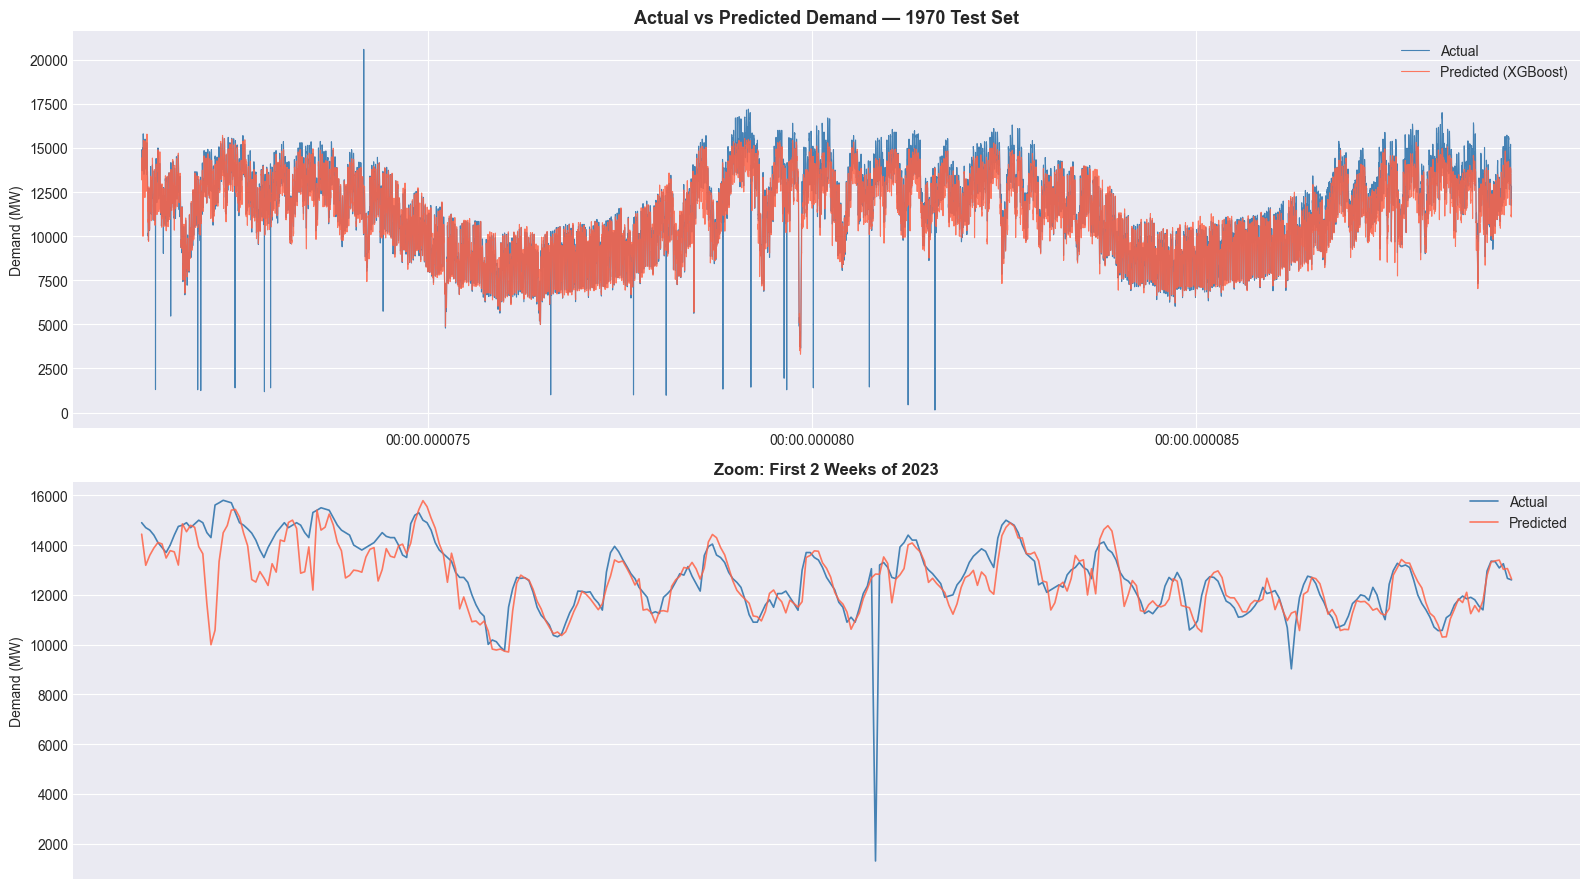

💾 Saved: 04_predictions.png


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9))

axes[0].plot(test_df.index, y_test.values, label='Actual', linewidth=0.8, color='steelblue')
axes[0].plot(test_df.index, best_pred, label=f'Predicted ({best_name})',
             linewidth=0.8, color='tomato', alpha=0.85)
axes[0].set_title(f'Actual vs Predicted Demand — {TEST_YEAR} Test Set', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Demand (MW)')
axes[0].legend()

zoom_end = test_df.index[min(336, len(test_df)-1)]
zoom_mask = test_df.index <= zoom_end
axes[1].plot(test_df.index[zoom_mask], y_test.values[zoom_mask],
             label='Actual', linewidth=1.2, color='steelblue')
axes[1].plot(test_df.index[zoom_mask], best_pred[zoom_mask],
             label=f'Predicted', linewidth=1.2, color='tomato', alpha=0.85)
axes[1].set_title('Zoom: First 2 Weeks of 2023', fontweight='bold')
axes[1].set_ylabel('Demand (MW)')
axes[1].legend()

plt.tight_layout()
plt.savefig('04_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

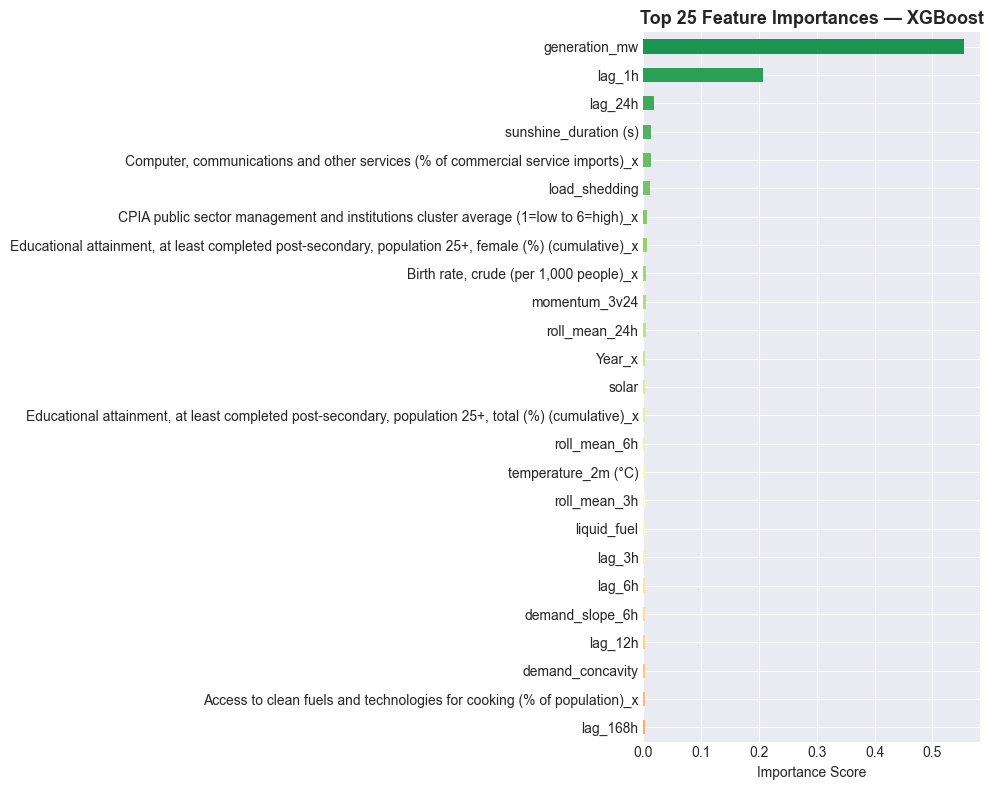

💾 Saved: 05_feature_importance.png

📊 Top 10 Features:
   generation_mw                  0.5546
   lag_1h                         0.2062
   lag_24h                        0.0176
   sunshine_duration (s)          0.0134
   Computer, communications and other services (% of commercial service imports)_x 0.0132
   load_shedding                  0.0116
   CPIA public sector management and institutions cluster average (1=low to 6=high)_x 0.0059
   Educational attainment, at least completed post-secondary, population 25+, female (%) (cumulative)_x 0.0055
   Birth rate, crude (per 1,000 people)_x 0.0038
   momentum_3v24                  0.0038


In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols)
    importances = importances.sort_values(ascending=False).head(25)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(importances))[::-1])
    importances.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(f'Top 25 Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('05_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n Top 10 Features:")
    for feat, imp in importances.head(10).items():
        print(f"   {feat:<30} {imp:.4f}")

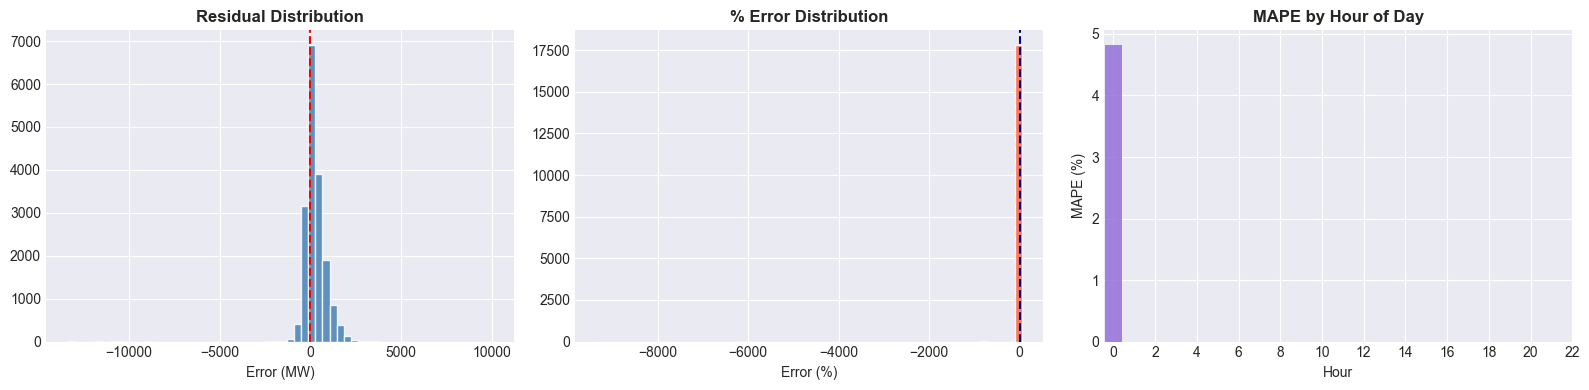

💾 Saved: 06_residuals.png


In [ ]:
residuals = y_test.values - best_pred
pct_errors = 100 * residuals / y_test.values

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residual Distribution', fontweight='bold')
axes[0].set_xlabel('Error (MW)')

axes[1].hist(pct_errors, bins=60, color='tomato', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='navy', linestyle='--')
axes[1].set_title('% Error Distribution', fontweight='bold')
axes[1].set_xlabel('Error (%)')

hourly_mape = pd.DataFrame({
    'hour': test_df.index.hour,
    'abs_pct_err': np.abs(pct_errors)
}).groupby('hour')['abs_pct_err'].mean()

axes[2].bar(hourly_mape.index, hourly_mape.values, color='mediumpurple', alpha=0.85)
axes[2].set_title('MAPE by Hour of Day', fontweight='bold')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('MAPE (%)')
axes[2].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('06_residuals.png', dpi=150, bbox_inches='tight')
plt.show()